<a href="https://colab.research.google.com/github/hxxn05/nvidia/blob/yolo/yolov8_images.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

0: 384x640 12 persons, 142.1ms
Speed: 5.1ms preprocess, 142.1ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)


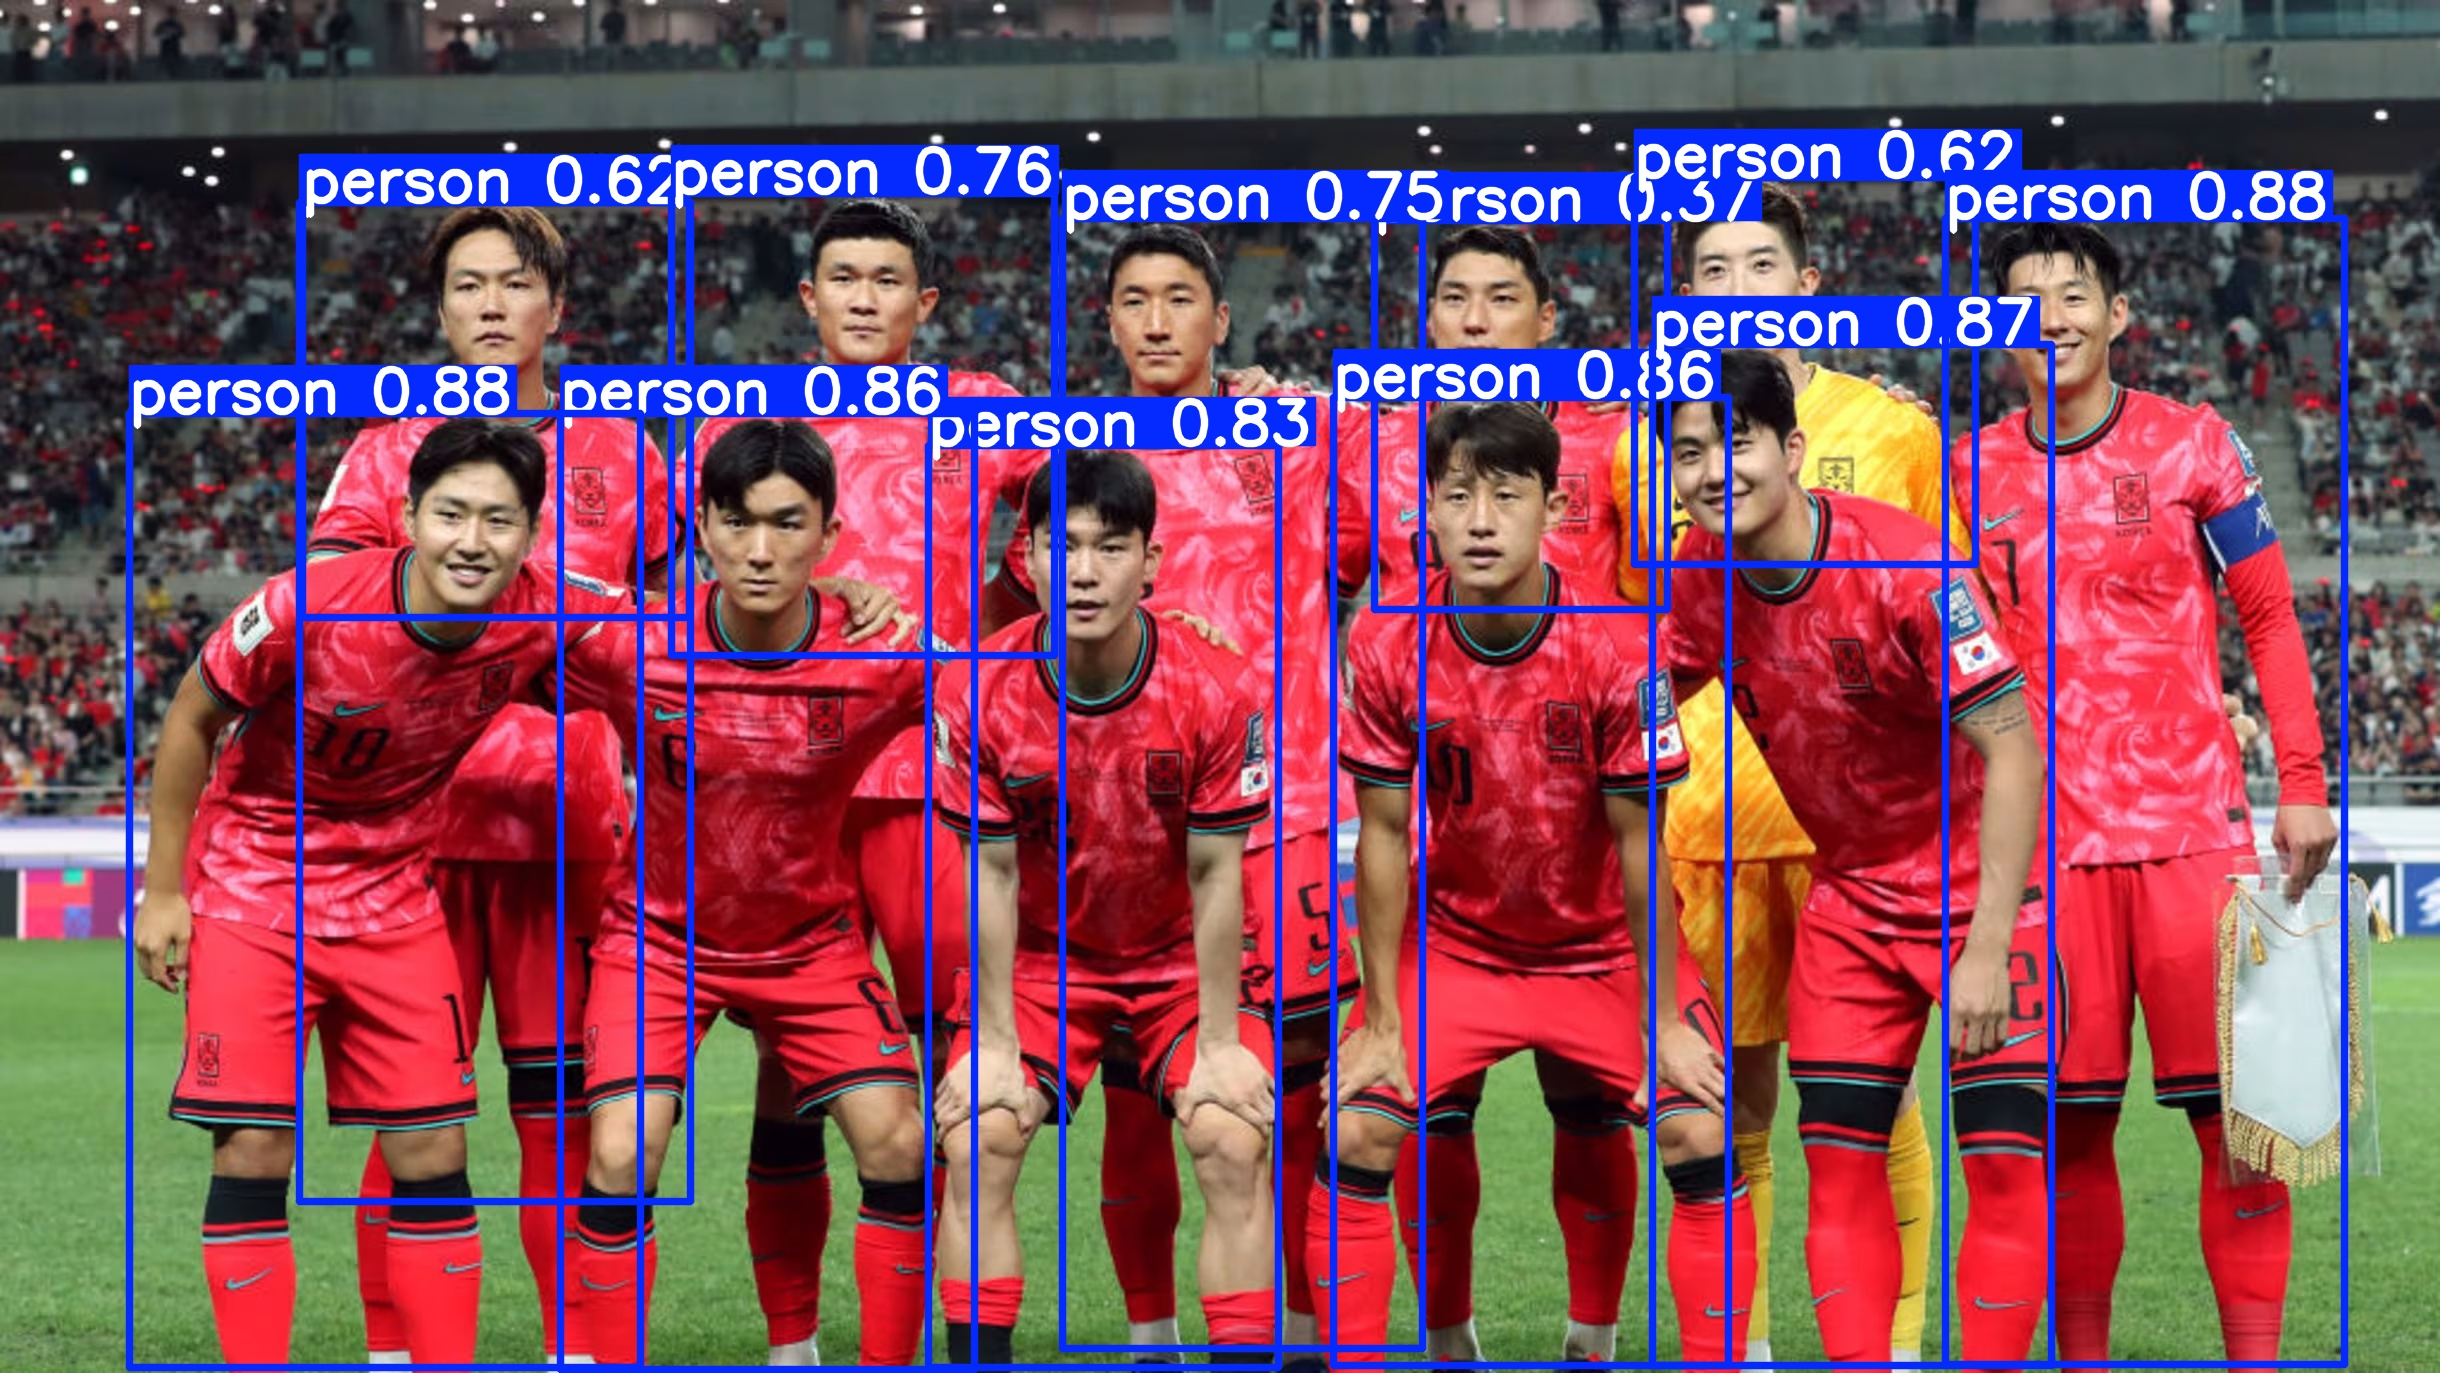

In [16]:
# 1. 필요한 라이브러리 설치
!pip install ultralytics  # YOLOv8 설치
!pip install opencv-python  # OpenCV 설치

# 2. 라이브러리 임포트
from ultralytics import YOLO
import cv2
import numpy as np
from google.colab.patches import cv2_imshow  # Colab에서 이미지 표시용
from IPython.display import display, Image  # 이미지 표시 추가
from google.colab import drive  # Google Drive 마운트용

# 3. Google Drive 마운트
drive.mount('/content/drive')  # Google Drive를 Colab에 연결

# 4. YOLOv8 모델 로드 (사전 학습된 모델 사용)
model = YOLO('yolov8n.pt')  # 경량 모델, 필요 시 'yolov8s.pt' 등으로 변경 가능

# 5. 사진 파일 물체 탐지 함수
def detect_objects_in_image(image_path):
    # 파일 읽기
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: '{image_path}' 파일을 읽을 수 없습니다.")
        return

    # YOLOv8으로 물체 탐지
    results = model(img)

    # 탐지 결과 시각화 및 저장
    annotated_img = results[0].plot()  # 탐지된 물체 박스와 라벨 표시
    output_path = '/content/annotated_image.jpg'
    cv2.imwrite(output_path, annotated_img)  # 이미지 저장

    # 이미지 표시
    display(Image(output_path))

# 6. 실행 (Google Drive에서 '1.png' 자동 가져오기)
image_path = '/content/drive/MyDrive/1.png'  # Google Drive 루트에 '1.png'가 있다고 가정
detect_objects_in_image(image_path)